In [ ]:
Gloria BADOHOUN, M2 TP Lab 1 

# **M2-INASYS / OPTIMSYS Course 1: Assignment**


## **Topic : Obesity modelling**

Overweight and obesity are considered by the WHO as serious health concerns. They pose health risks to all individuals living with these conditions. The WHO defines obesity as an abnormal or excessive accumulation of body fat that significantly impacts both a patient’s daily life and overall health.

Faced with this serious health issue, imagine you have been tasked with modeling the problem. The goal is to build a predictive model using historical data about people suffering from obesity, in order to guide public health measures. Based on specific characteristics, the model would help determine an individual’s level or risk of obesity.

![image.png](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQzA1xo7EZ1ZHwDutoxg7416XBcErk_P7f0Pg&s)


As **SARA la Data**, go to https://github.com/EDJINEDJA/Health-Data-modelling.git to download historical information about people suffering from obesity in order to begin the modeling process. The data, located in the **lab1** folder and in CSV format (Comma-Separated Values), is now your property. Enjoy!

*!!!!!!* **The expected files are: the report and the code.**

# **Section 1**

### **Part 1**

#### Q1: Use both your clinical knowledge and data analysis background to describe and present the data provided to you.

(1000, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    1000 non-null   int64  
 1   Gender                 1000 non-null   str    
 2   Height                 1000 non-null   float64
 3   Weight                 1000 non-null   float64
 4   BMI                    1000 non-null   float64
 5   PhysicalActivityLevel  1000 non-null   int64  
 6   ObesityCategory        1000 non-null   str    
dtypes: float64(3), int64(2), str(2)
memory usage: 54.8 KB
Age                      0
Gender                   0
Height                   0
Weight                   0
BMI                      0
PhysicalActivityLevel    0
ObesityCategory          0
dtype: int64
0


,Age,Height,Weight,BMI,PhysicalActivityLevel
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.857000,170.052417,71.205769,24.888317,2.534000
std,18.114267,10.309971,15.509849,6.193912,1.116284
min,18.000000,136.115719,26.065730,8.470572,1.000000
25%,35.000000,163.514205,61.129629,20.918068,2.000000
50%,50.000000,169.801665,71.929072,24.698647,3.000000
75%,66.000000,177.353596,81.133746,28.732132,4.000000
max,79.000000,201.419670,118.907366,50.791898,4.000000


ObesityCategory
Normal weight    371
Overweight       295
Obese            191
Underweight      143
Name: count, dtype: int64
Gender
Male      523
Female    477
Name: count, dtype: int64
PhysicalActivityLevel
1    239
2    247
3    255
4    259
Name: count, dtype: int64


<Axes: xlabel='ObesityCategory'>

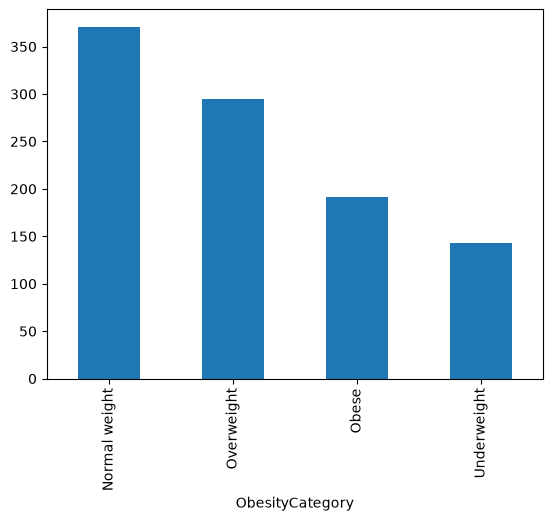

In [1]:
import pandas as pd
df = pd.read_csv("obesity_data.csv")
print(df.shape)
df.info()
print(df.isna().sum())
print(df.duplicated().sum())
display(df.describe())
print(df["ObesityCategory"].value_counts())
print(df["Gender"].value_counts())
print(df["PhysicalActivityLevel"].value_counts().sort_index())
df["ObesityCategory"].value_counts().plot(kind="bar")

Answer : Answer: The dataset contains 1000 individuals and 7 variables, with no missing values and no duplicated rows. Numerical variables: Age (18–79 years, mean ≈ 50), Height (136–201 cm), Weight (26–119 kg), BMI (8.5–50.8, mean ≈ 24.9) and PhysicalActivityLevel (ordinal, 1 to 4, roughly balanced). Categorical variables: Gender (523 male, 477 female) and ObesityCategory (Normal weight 371, Overweight 295, Obese 191, Underweight 143), which shows a moderate class imbalance.
Clinically, BMI = weight (kg) / height (m)². The WHO thresholds are: underweight < 18.5, normal 18.5–24.9, overweight 25–29.9, obese ≥ 30. We checked that ObesityCategory is exactly determined by BMI in this dataset, so BMI carries the label information (data leakage risk). Some extreme values (e.g. BMI of 8.5) are clinically implausible, which suggests the data is synthetic.

### **Part 2**

#### Q2 : What kind of learning do you need to extract knowledge?

Answer : Supervised learning, because the historical data contains the outcome we want to predict (ObesityCategory) for each individual, so the model learns from labelled examples.

Q3 : Which task of the selected type of learning do you need to perform to extract knowledge?

Answer : Classification (multi-class, 4 classes: Underweight, Normal weight, Overweight, Obese), since the target is a discrete category and not a continuous value (which would be regression).

Q4 : Define and comment on the evaluation metrics you need to select the best model. Justify your answer rigorously with examples.

Answer : Accuracy = correct predictions / all predictions; easy to read, but misleading with imbalanced classes (always predicting "Normal weight" already gives ≈ 37%). Precision = TP / (TP + FP): among people predicted in a class, how many truly belong to it. Recall = TP / (TP + FN): among people truly in a class, how many are found. In public health, a low recall for "Obese" means at-risk people are missed, which is costlier than a false alarm. F1-score = harmonic mean of precision and recall; we use the macro-average so that every class counts equally despite the imbalance. The confusion matrix shows which classes get confused (e.g. Overweight vs Obese). We therefore select the best model mainly on macro F1 and recall, with accuracy as a complement.

Q5 : According to the defined problem, what is the variable of interest?

Answer : The variable of interest (target) is ObesityCategory, the obesity level we want to predict.

Q6 : Still in this context, what is the explanatory variable?

Answer : The explanatory variables (features) are Age, Gender, Height, Weight and PhysicalActivityLevel. BMI is also available but is excluded from the model because it is computed from Height and Weight and it directly defines the target categories (data leakage).

## **Part3**

Q7 : Since computers cannot interpret categorical variables directly, it is necessary to preprocess the data to make it machine-readable. Do not hesitate to perform further data processing (e.g., handling missing values, removing irrelevant variables, etc.).

In [2]:
df_model = df.drop(columns=["BMI"])
df_model["Gender"] = df_model["Gender"].map({"Female": 0, "Male": 1})

X = df_model.drop(columns="ObesityCategory")
y = df_model["ObesityCategory"]

print(df_model.isna().sum().sum())
X.head()

0


,Age,Gender,Height,Weight,PhysicalActivityLevel
0,56,1,173.575262,71.982051,4
1,69,1,164.127306,89.959256,2
2,46,0,168.072202,72.930629,4
3,32,1,168.459633,84.886912,3
4,60,1,183.568568,69.038945,3


Answer : No missing values were found, so no imputation was needed. BMI was removed because it is a deterministic function of Height and Weight and it defines the target (data leakage); keeping it would give an artificially perfect model. Gender was encoded as a binary numeric variable (Female = 0, Male = 1). PhysicalActivityLevel is already numeric and ordinal. The target stays as text labels, which scikit-learn accepts. X contains the 5 features and y the target.

## **Part 4**

One problem we encountered during the learning process is the issue of generalizability. It is a phenomenon where the model overlearns, including the noise in the data, which limits its ability to perform well on unseen data.

That is why, in order to perform good modelling, it is essential to keep a portion of the data aside to evaluate the model after training. This helps give an idea of how well the training actually worked.

![image.png](https://miro.medium.com/1*0mYlQihIDkCziGeYO-ePCQ.png)

Typical splits are 60% for training and 40% for testing or 80/20.

Q8: Split the overall dataset into a training set and a test set

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((800, 5), (800,), (200, 5), (200,))

Explication : 80/20 split: 800 individuals to train, 200 to test. 

stratify=y keeps the same class proportions in both sets (important because the classes are imbalanced), 
and random_state=42 makes the result reproducible.

## **Part 5**

#### Q9 : Build a decision tree model using Scikit-learn. Keep the default hyperparameters of the chosen algorithm. Specify which decision tree algorithm was used.
See the documentation here: https://scikit-learn.org/.

Answer: Algorithm used: CART (Classification And Regression Trees), 
which is the algorithm implemented by scikit-learn's DecisionTreeClassifier. With default hyperparameters,
it selects splits by minimizing the Gini impurity and builds binary splits. random_state=42 is only set for reproducibility.

In [5]:
from sklearn.tree import DecisionTreeClassifier

model1 = DecisionTreeClassifier(random_state=42)   # hyperparamètres par défaut
model1.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples

#### Q10 : Use the test set to evaluate how well your model generalizes to unseen data. Provide a clear explanation of all the evaluation metrics used.

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred1 = model1.predict(X_test)
print("Train accuracy:", model1.score(X_train, y_train))
print("Test accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))
print(model1.classes_)
print(confusion_matrix(y_test, y_pred1, labels=model1.classes_))

Train accuracy: 1.0
Test accuracy: 0.915
               precision    recall  f1-score   support

Normal weight       0.90      0.96      0.93        74
        Obese       0.92      0.92      0.92        38
   Overweight       0.91      0.88      0.90        59
  Underweight       0.96      0.86      0.91        29

     accuracy                           0.92       200
    macro avg       0.92      0.91      0.91       200
 weighted avg       0.92      0.92      0.91       200

['Normal weight' 'Obese' 'Overweight' 'Underweight']
[[71  0  2  1]
 [ 0 35  3  0]
 [ 4  3 52  0]
 [ 4  0  0 25]]


Answer : Answer: Test accuracy = 91.5% (183 of 200 correct), macro F1 = 0.914, macro precision = 0.923, macro recall = 0.906. Per class (precision / recall): Normal weight 0.90 / 0.96, Obese 0.92 / 0.92, Overweight 0.91 / 0.88, Underweight 0.96 / 0.86.
Metrics: accuracy = share of correct predictions. Precision = TP / (TP + FP), how reliable a predicted class is. Recall = TP / (TP + FN), the share of real cases of a class that are found. F1 = harmonic mean of precision and recall; macro averages treat every class equally. The confusion matrix (rows = true class, columns = predicted) shows the errors: 4 Overweight and 4 Underweight individuals were predicted as Normal weight, and 3 Overweight as Obese; errors are mostly between neighbouring categories.
Generalization: the training accuracy is 100% versus 91.5% on the test set. This gap shows overfitting: the unconstrained tree (depth 10, 60 leaves) memorized the training data, including noise, and loses about 8.5 points on unseen data.

## **Part 6**

Q11 : Using the same algorithm, propose an alternative criterion for selecting the root node.

In [7]:
model2 = DecisionTreeClassifier(criterion="entropy", random_state=42)
model2.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samp

Q12 : Use the test set to evaluate how well your new model generalizes to unseen data.

Answer (Q11 + Q12): The alternative criterion is entropy (information gain) instead of Gini impurity, with the same CART algorithm. The root node is the feature/threshold giving the largest reduction in entropy.
Model 2 reaches a test accuracy of 94.5% (189/200), macro F1 = 0.946, macro precision = 0.946, macro recall = 0.947, versus 91.5% and macro F1 = 0.914 for Model 1. Recall improves for Obese (0.97 vs 0.92), Overweight (0.95 vs 0.88) and Underweight (0.93 vs 0.86), and only 11 individuals are misclassified instead of 17. However, its training accuracy is also 100% (depth 11, 52 leaves), so it still overfits. Since the test set has only 200 individuals, the 3-point gain should be confirmed with cross-validation before concluding that entropy is better.

In [8]:
y_pred2 = model2.predict(X_test)
print("Train accuracy:", model2.score(X_train, y_train))
print("Test accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2, labels=model2.classes_))

Train accuracy: 1.0
Test accuracy: 0.945
               precision    recall  f1-score   support

Normal weight       0.95      0.93      0.94        74
        Obese       0.97      0.97      0.97        38
   Overweight       0.93      0.95      0.94        59
  Underweight       0.93      0.93      0.93        29

     accuracy                           0.94       200
    macro avg       0.95      0.95      0.95       200
 weighted avg       0.95      0.94      0.94       200

[[69  0  3  2]
 [ 0 37  1  0]
 [ 2  1 56  0]
 [ 2  0  0 27]]


### **Part 7**

Q13 : Display the decision tree for both Model 1 and Model 2.

##### For model1

In [9]:
import sys
!{sys.executable} -m pip install graphviz
from graphviz import Source

from IPython.display import display, SVG
from sklearn.tree import export_graphviz

In [10]:
graph = Source(export_graphviz(model1, out_file=None, feature_names=X.columns,
                               class_names=list(model1.classes_), filled=True, rounded=True))

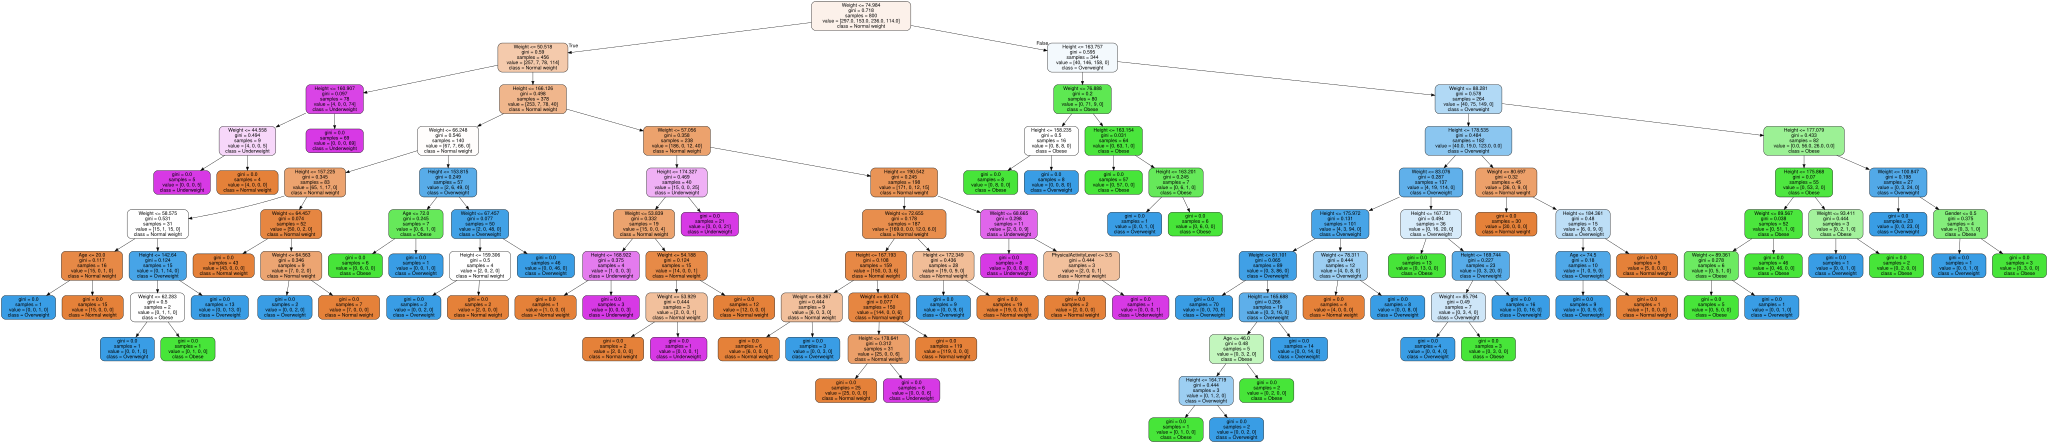

In [11]:
# The following requires graphviz on your computer
display(SVG(graph.pipe(format='svg')))

##### For model2

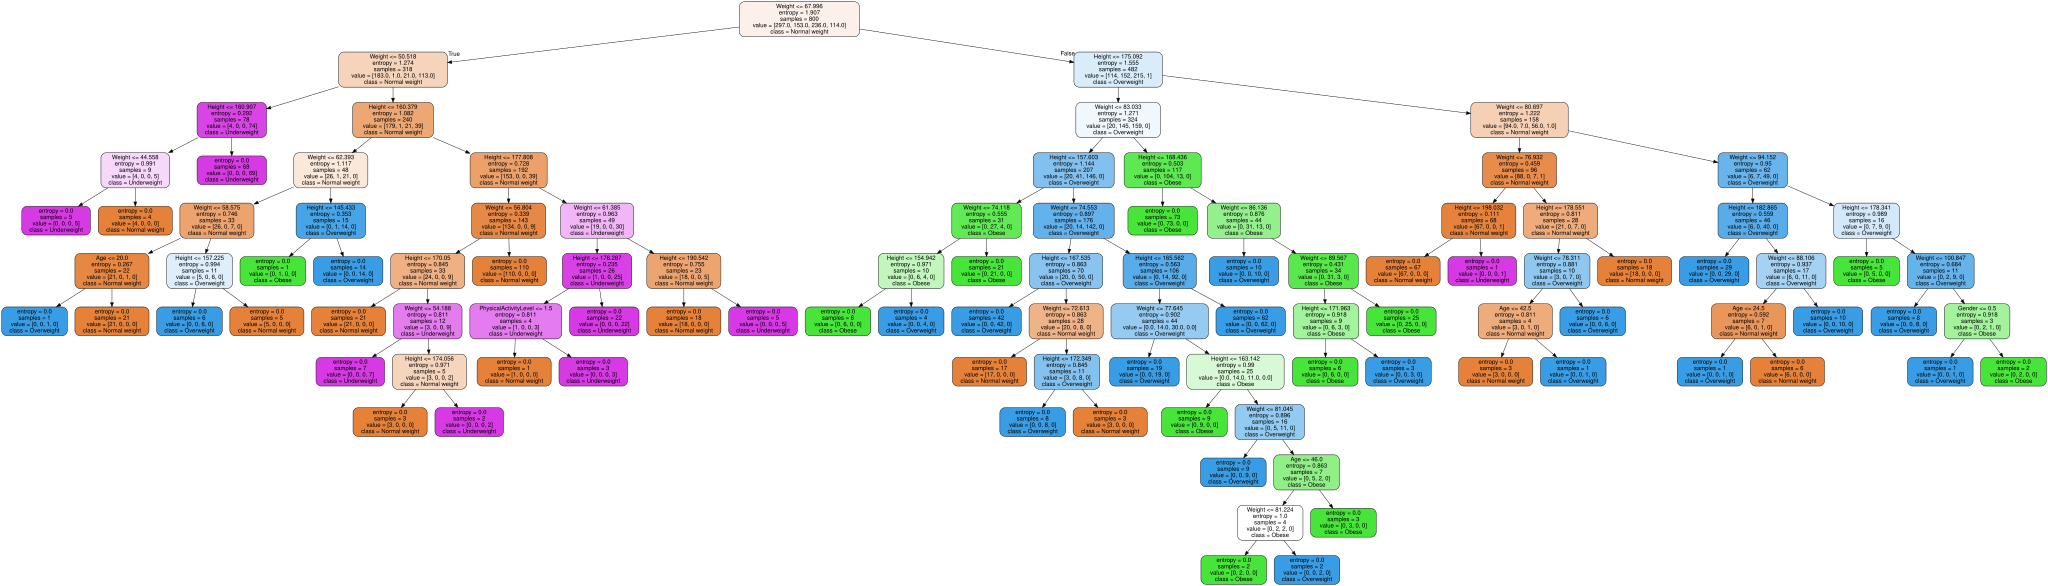

In [12]:
graph2 = Source(export_graphviz(model2, out_file=None, feature_names=X.columns,
                                class_names=list(model2.classes_), filled=True, rounded=True))
display(SVG(graph2.pipe(format="svg")))

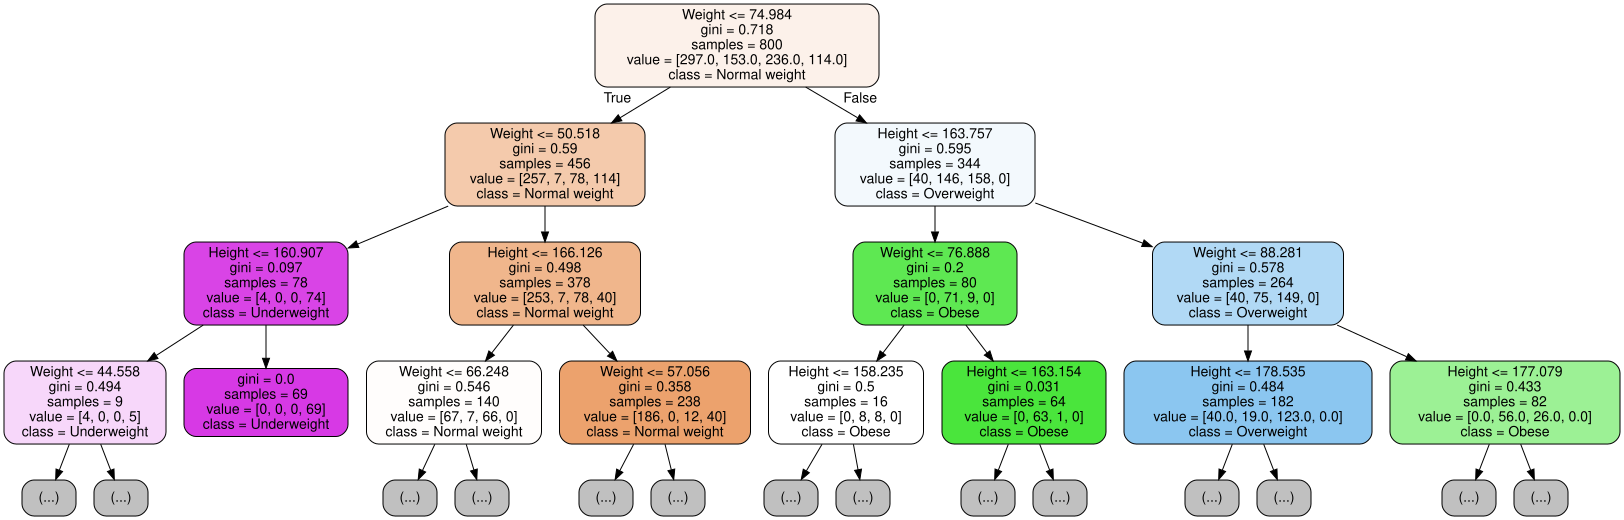

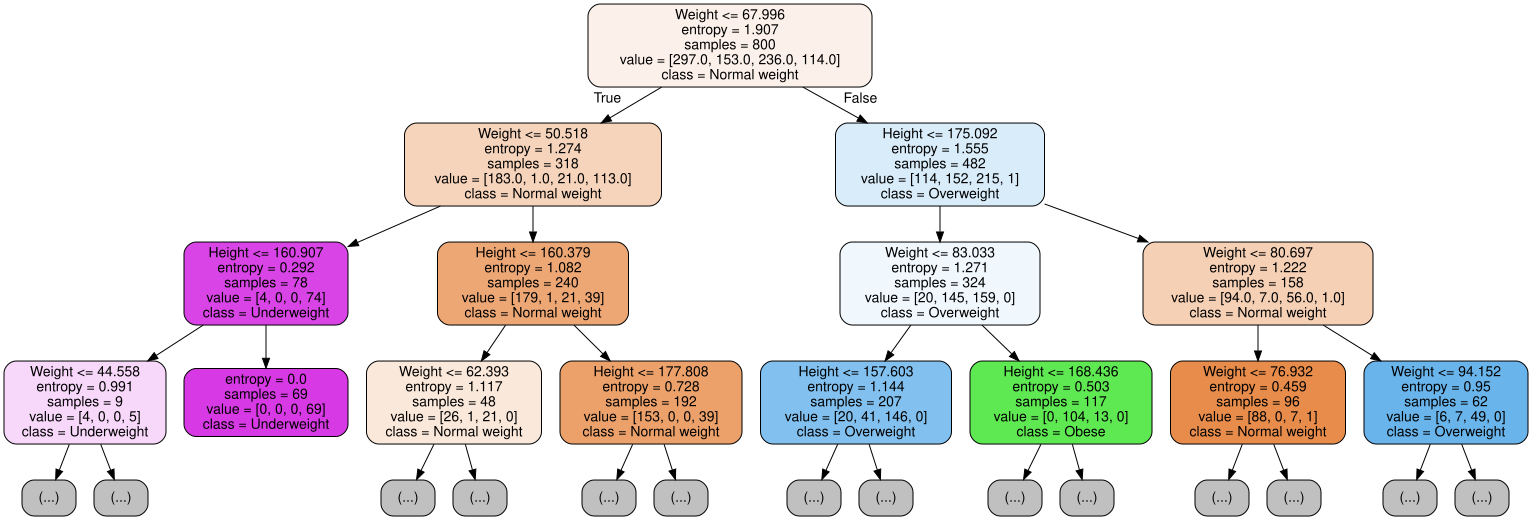

In [13]:
display(SVG(Source(export_graphviz(model1, out_file=None, feature_names=X.columns,
        class_names=list(model1.classes_), filled=True, rounded=True, max_depth=3)).pipe(format="svg")))
display(SVG(Source(export_graphviz(model2, out_file=None, feature_names=X.columns,
        class_names=list(model2.classes_), filled=True, rounded=True, max_depth=3)).pipe(format="svg")))

Answer: Both trees are displayed above (full trees, then a truncated view of the first 3 levels for readability). Model 1 (Gini) has a depth of 10 and 60 leaves; its root node splits on Weight (≈ 75.0 kg). Model 2 (entropy) has a depth of 11 and 52 leaves; its root node also splits on Weight (≈ 68.0 kg). In both trees, Weight and Height are the most used variables, while Age, Gender and PhysicalActivityLevel play almost no role.

Q14 : Explain which one is more interpretable. Give your reasons.

Answer: Neither full tree is truly interpretable: with 52 to 60 leaves and 10 to 11 levels, a clinician cannot follow the rules by hand. Model 2 is slightly more interpretable because it has fewer leaves (52 vs 60), hence fewer decision rules, even though it is one level deeper. Its first levels, like those of Model 1, are easy to read (a threshold on Weight, then on Height), which matches clinical knowledge of BMI. Since both trees overfit (100% training accuracy), limiting the depth (e.g. max_depth=3 or pruning) would give a much more readable model at a small cost in accuracy.

# **Section 2**

Now you will test one of the algorithms used to construct a decision tree! In this section, we will see how to perform this from scratch.

Therefore, due to the complexity involved in the construction, we will use another binary dataset available in the same folder under the name obesity_binary.

#### *Construct a decision tree using the ID3 algorithm based on information gain.*

**Information Gain**

Information Gain measures the reduction in entropy about the target variable after splitting a dataset based on a particular feature.

![image.png](https://spicerrobotboy.files.wordpress.com/2012/01/decision-tree-equations.png)


Q15 : Load data

In [14]:
import numpy as np
import pandas as pd
from graphviz import Digraph

data = pd.read_csv("obesity_binary.csv")
target = "ObesityCategory"
attrs = [c for c in data.columns if c != target]
display(data)

,Age,Gender,Height,Weight,BMI,PhysicalActivityLevel,ObesityCategory
0,0,0,1,0,0,1,0
1,1,1,0,1,1,0,1
2,0,1,1,1,1,0,1
3,1,0,1,1,1,0,1
4,1,1,0,0,0,1,0
5,0,0,0,1,1,1,1
6,0,1,1,0,0,1,0
7,1,0,0,1,1,0,1


Answer: The file obesity_binary.csv contains 8 individuals and 7 binary (0/1) variables: Age, Gender, Height, Weight, BMI, PhysicalActivityLevel and the target ObesityCategory (3 individuals in class 0, 5 in class 1). There are no missing values. All the attributes are already binary, so no encoding is required.

Q16 : Which attribute should be chosen for the root node?

In [15]:
def entropy(s):
    p = s.value_counts(normalize=True)
    return -(p * np.log2(p)).sum()

def info_gain(df, attr):
    total = entropy(df[target])
    weighted = sum(len(sub) / len(df) * entropy(sub[target]) for _, sub in df.groupby(attr))
    return total - weighted

print("Entropy of the target:", round(entropy(data[target]), 4))
for a in attrs:
    print(a, round(info_gain(data, a), 4))

Entropy of the target: 0.9544
Age 0.0488
Gender 0.0488
Height 0.0488
Weight 0.9544
BMI 0.9544
PhysicalActivityLevel 0.5488


Answer: The file obesity_binary.csv contains 8 individuals and 7 binary (0/1) variables: Age, Gender, Height, Weight, BMI, PhysicalActivityLevel and the target ObesityCategory (3 individuals in class 0, 5 in class 1). There are no missing values. All the attributes are already binary, so no encoding is required.

Q17 : Write a function to build the tree and visualize the tree.

Answer: The entropy of the target is H(S) = -(3/8)log2(3/8) - (5/8)log2(5/8) = 0.9544. The information gain is IG(S, A) = H(S) - Σ (|Sv|/|S|) H(Sv). Results: Age 0.0488, Gender 0.0488, Height 0.0488, PhysicalActivityLevel 0.5488, Weight 0.9544, BMI 0.9544. Weight and BMI tie with the maximum gain (0.9544 = the whole entropy): each of them separates the two classes perfectly. The root node is therefore Weight (first maximum in column order); choosing BMI would give an equivalent tree.

Q18 : What is the maximum depth of the tree?

Answer (Q18): The maximum depth is 1 (one split, on Weight, is enough).

Q19 : How many leaf nodes do you have?

Answer (Q19): The tree has 2 leaf nodes (Weight = 0 → class 0, Weight = 1 → class 1).

# **section 3**

Q20: Repeat the exercise (section 2) for the C4.5 algorithm.

Answer: C4.5 improves ID3 by choosing the attribute with the highest gain ratio = information gain / split information, which penalizes attributes with many values (a bias of ID3). C4.5 also handles continuous attributes (thresholds), missing values and post-pruning; these are not needed here because all attributes are binary and complete. Gain ratios: Age, Gender, Height 0.0488; PhysicalActivityLevel 0.5488; Weight 1.0; BMI 1.0. Weight and BMI tie again, so the root is Weight, and the tree is identical to the ID3 tree: {Weight: {0 → 0, 1 → 1}}, depth 1, 2 leaves. On this small binary dataset, both algorithms give the same result because Weight (like BMI) perfectly separates the classes.

Age 0.0488
Gender 0.0488
Height 0.0488
Weight 1.0
BMI 1.0
PhysicalActivityLevel 0.5488
{'Weight': {0: 0, 1: 1}} | depth: 1 | leaves: 2


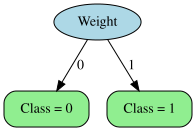

In [16]:
import numpy as np
import pandas as pd
from graphviz import Digraph

data = pd.read_csv("obesity_binary.csv")
target = "ObesityCategory"
attrs = [c for c in data.columns if c != target]

def entropy(s):
    p = s.value_counts(normalize=True)
    return -(p * np.log2(p)).sum()

def info_gain(df, attr):
    total = entropy(df[target])
    weighted = sum(len(sub) / len(df) * entropy(sub[target]) for _, sub in df.groupby(attr))
    return total - weighted

def split_info(df, attr):
    p = df[attr].value_counts(normalize=True)
    return -(p * np.log2(p)).sum()

def gain_ratio(df, attr):
    si = split_info(df, attr)
    return info_gain(df, attr) / si if si > 0 else 0

def build_tree(df, attrs, criterion=info_gain):
    if df[target].nunique() == 1:
        return int(df[target].iloc[0])
    if not attrs:
        return int(df[target].mode()[0])
    scores = {a: criterion(df, a) for a in attrs}
    best = max(scores, key=scores.get)
    tree = {best: {}}
    for value, sub in df.groupby(best):
        rest = [a for a in attrs if a != best]
        tree[best][int(value)] = build_tree(sub, rest, criterion)
    return tree

def depth(t):
    return 0 if not isinstance(t, dict) else 1 + max(depth(c) for c in next(iter(t.values())).values())

def leaves(t):
    return 1 if not isinstance(t, dict) else sum(leaves(c) for c in next(iter(t.values())).values())

def draw(tree):
    g = Digraph()
    n = [0]
    def walk(t):
        n[0] += 1
        me = str(n[0])
        if not isinstance(t, dict):
            g.node(me, f"Class = {t}", shape="box", style="filled,rounded", fillcolor="lightgreen")
            return me
        attr = next(iter(t))
        g.node(me, attr, shape="ellipse", style="filled", fillcolor="lightblue")
        for v, child in t[attr].items():
            g.edge(me, walk(child), label=str(v))
        return me
    walk(tree)
    return g

for a in attrs:
    print(a, round(gain_ratio(data, a), 4))

tree_c45 = build_tree(data, attrs, gain_ratio)
print(tree_c45, "| depth:", depth(tree_c45), "| leaves:", leaves(tree_c45))
draw(tree_c45)